## 0. Импорт библиотек и ввод данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

In [2]:
folder_path = r'..\data\raw'
file_type = '/*csv'

files = glob.glob(folder_path + file_type)

latest_file = max(files, key=os.path.getctime)

time = latest_file[12:].split(sep="_")

access_time = pd.Timestamp(
    year=int(time[0][0:4]),
    month=int(time[0][4:6]),
    day=int(time[0][6:8]),
    hour=int(time[1][0:2]),
    minute=int(time[1][2:4]),
    tz='Europe/Moscow'
)

df = pd.read_csv(latest_file)

In [3]:
print(access_time)

2026-04-26 13:10:00+03:00


## 1. Общие сведения о датасете.

In [4]:
df = df[df['price_byn'] > 10]

#### После Логарифмирования распределенеие стало колоколо-образным, а значит в нашем случае данные образуют логнормальное распредел

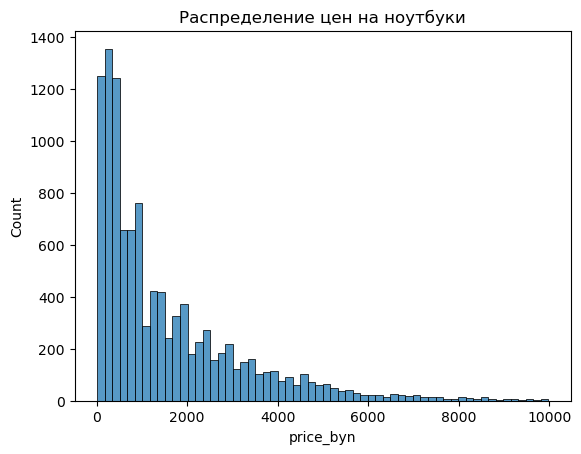

In [5]:
sns.histplot(data=df[df['price_byn'] < 10000], x = 'price_byn')

plt.title('Распределение цен на ноутбуки')

plt.show()

<Axes: >

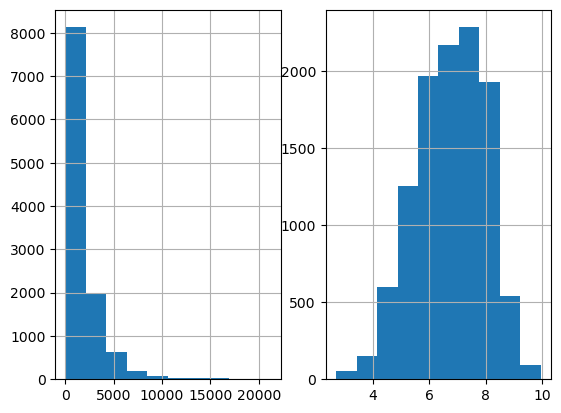

In [6]:
fig, axes = plt.subplots(1, 2)
df['price_byn'].hist(ax=axes[0])
np.log(df['price_byn']).hist(ax=axes[1])

Очень много пропусков из 11053 объявлений всего в 1400 заполнены все собранные нами данные.
Больше всего пропусков в бренде видеокарты. Хотя, параметр важный, возможно имеет смысл полностью от него избавиться.

In [7]:
print(f"Shape: {df.shape}")
print(f"Shape: {df.shape}")
print("\n==================================\n")
print(df.isna().sum())
print("\n==================================\n")
print(df.info())
print("\n==================================\n")
print(df.describe())

Shape: (11052, 21)
Shape: (11052, 21)


ad_id                    0
subject                  0
price_byn                0
company_ad               0
list_time                0
condition                0
brand                 1945
processor             4196
rom_volume            5341
rom_type              4074
diagonal              4727
os                    3484
videocard             6419
videocard_brand       8509
region                   0
gaming_laptop         7608
matrix_type           6679
display_resolution    4598
ram_volume            4517
ram_type              6716
battery_life          6731
dtype: int64


<class 'pandas.core.frame.DataFrame'>
Index: 11052 entries, 0 to 11749
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ad_id               11052 non-null  int64  
 1   subject             11052 non-null  object 
 2   price_byn           11052 non-null  float64
 3   company_ad          1105

In [8]:
print("Количество товаров с полностью заполнеными данными:", df.dropna().shape[0], 'из', df.shape[0])

Количество товаров с полностью заполнеными данными: 725 из 11052


### Количеств уникальных значений для каждого параметра

In [9]:
df.nunique()

ad_id                 11052
subject                9056
price_byn              2341
company_ad                2
list_time              9807
condition                 2
brand                    25
processor                52
rom_volume                5
rom_type                 10
diagonal                 19
os                       12
videocard                 3
videocard_brand         129
region                    7
gaming_laptop             2
matrix_type               4
display_resolution       16
ram_volume               13
ram_type                 10
battery_life              6
dtype: int64

### Распределение товарных позиций по регионам.

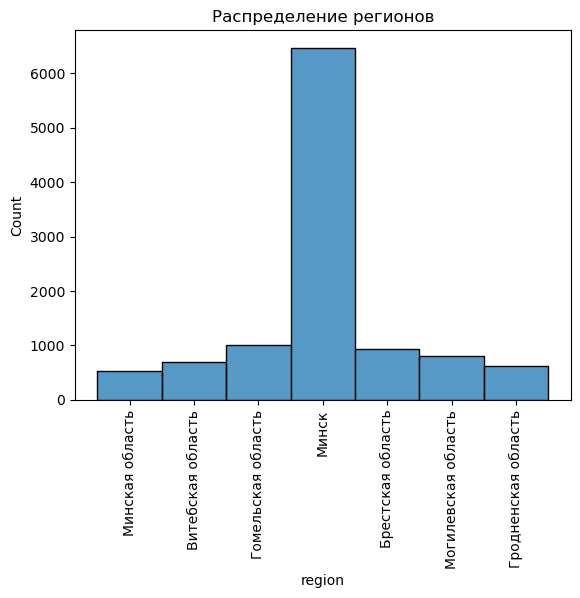

In [10]:
sns.histplot(data=df, x='region')
plt.title('Распределение регионов')
plt.xticks(rotation=90)
plt.show()

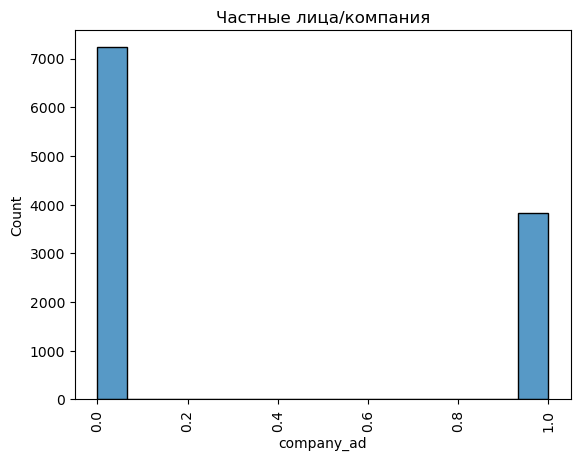

In [11]:
sns.histplot(data=df, x='company_ad')
plt.title('Частные лица/компания')
plt.xticks(rotation=90)
plt.show()

### Cамые популярные видеокарты.

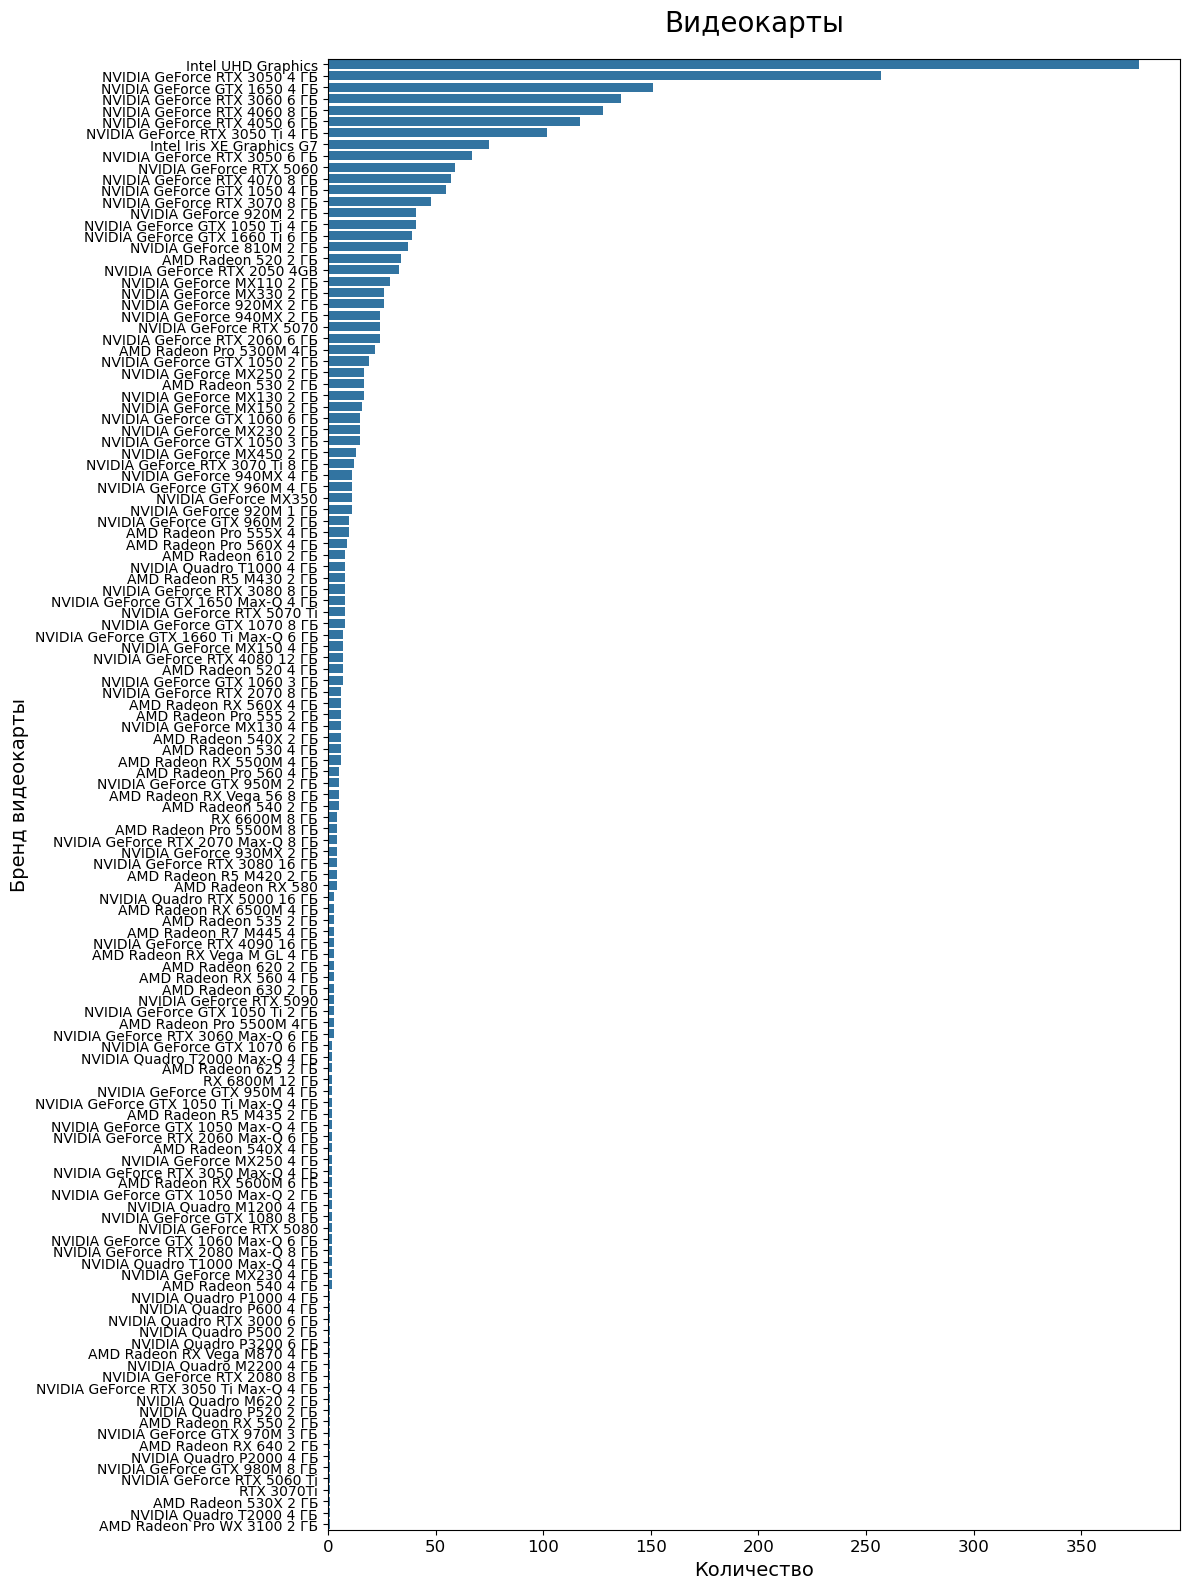

In [12]:
plt.figure(figsize=(12, 16))

order = df['videocard_brand'].value_counts().index

ax = sns.countplot(data=df, y='videocard_brand', order=order)

plt.title('Видеокарты', fontsize=20, pad=20)
plt.xlabel('Количество', fontsize=14)
plt.ylabel('Бренд видеокарты', fontsize=14)

ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()

Многие пользователи указали встроенную графику как дискретную видеокарту. Надо исправить.

### Популярность различных видов матриц.

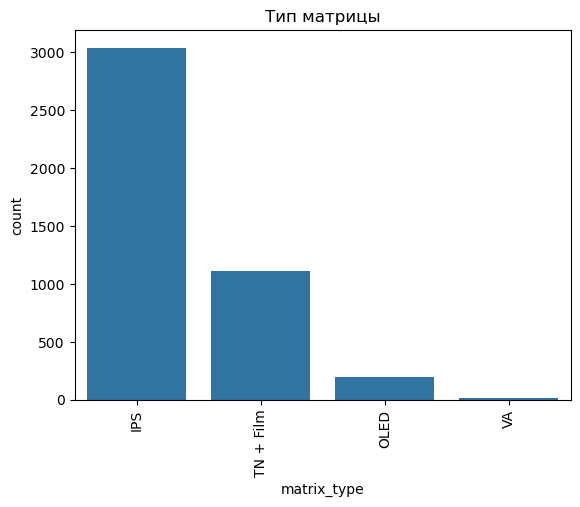

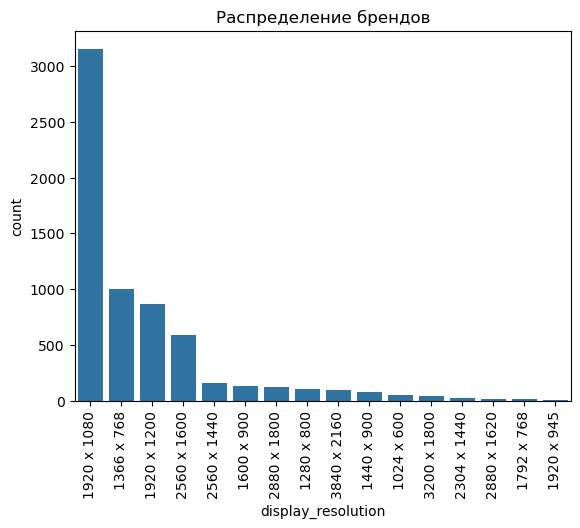

In [13]:
brand_order = df['matrix_type'].value_counts().index
sns.countplot(data=df, x='matrix_type', order=brand_order)
plt.title('Тип матрицы')
plt.xticks(rotation=90)
plt.show()

brand_order = df['display_resolution'].value_counts().index
sns.countplot(data=df, x='display_resolution', order=brand_order)
plt.title('Распределение брендов')
plt.xticks(rotation=90)
plt.show()

Слишком много значений разрешения. Возможно имеет смысл создать искусственный параметр число/плотность пикселей. Также можно нестандартные по соотношению матрицы включить или заменить более популярными значениями, схожими по качеству (например: 1920x945 на 1920x1080)

## 2. Заполнение пропущенных значений и обработка даных

In [14]:
print(df.nunique())
print('==========================================')
print('Уникальные значения различных параметров')
print(f'1. os: {df['os'].unique()}')
print(f'2. videocard: {df['videocard'].unique()}')
print(f'3. processor: {df['processor'].unique()}')
print(f'4. rom_type: {df['rom_type'].unique()}')
print(f'5. diagonal: {df['diagonal'].unique()}')
print(f'6. ram_volume: {df['ram_volume'].unique()}')
print(f'7. ram_type: {df['ram_type'].unique()}')
print(f'8. battery_life: {df['battery_life'].unique()}')
print(f'9. company_ad: {df['company_ad'].unique()}')

ad_id                 11052
subject                9056
price_byn              2341
company_ad                2
list_time              9807
condition                 2
brand                    25
processor                52
rom_volume                5
rom_type                 10
diagonal                 19
os                       12
videocard                 3
videocard_brand         129
region                    7
gaming_laptop             2
matrix_type               4
display_resolution       16
ram_volume               13
ram_type                 10
battery_life              6
dtype: int64
Уникальные значения различных параметров
1. os: [nan 'Windows 11' 'Windows 10' 'Mac OS' 'Windows 8' 'без ОС' 'OS X'
 'Windows XP' 'Windows 7' 'Linux' 'Прочее' 'Windows Vista' 'DOS']
2. videocard: [nan 'Встроенная' 'Встроенная и дискретная' 'Дискретная']
3. processor: [nan 'Intel Core i3' 'AMD A6' 'AMD E2' 'Intel Core i5' 'Apple M1'
 'Apple M1 Pro' 'AMD A4' 'Intel Core i7' 'Intel Core Pentium'
 'A

In [15]:
df['videocard_brand'].unique()

array([nan, 'NVIDIA GeForce RTX 4050 6 ГБ',
       'NVIDIA GeForce RTX 3050 6 ГБ', 'NVIDIA GeForce RTX 4060 8 ГБ',
       'NVIDIA GeForce RTX 3050 Ti 4 ГБ', 'NVIDIA GeForce RTX 3050 4 ГБ',
       'NVIDIA GeForce GTX 1650 4 ГБ', 'Intel UHD Graphics',
       'NVIDIA GeForce RTX 2050 4GB', 'NVIDIA GeForce 940MX 4 ГБ',
       'AMD Radeon 610 2 ГБ', 'NVIDIA GeForce GTX 1070 6 ГБ',
       'NVIDIA GeForce GTX 1060 6 ГБ', 'NVIDIA GeForce GTX 960M 2 ГБ',
       'NVIDIA GeForce GTX 1050 4 ГБ', 'AMD Radeon RX 5500M 4 ГБ',
       'NVIDIA Quadro P1000 4 ГБ', 'NVIDIA Quadro T1000 4 ГБ',
       'NVIDIA GeForce GTX 1050 3 ГБ', 'NVIDIA GeForce RTX 3060 6 ГБ',
       'NVIDIA Quadro T2000 Max-Q 4 ГБ', 'NVIDIA GeForce MX150 2 ГБ',
       'AMD Radeon Pro 5300M 4ГБ', 'NVIDIA GeForce MX110 2 ГБ',
       'NVIDIA GeForce RTX 3070 8 ГБ', 'Intel Iris XE Graphics G7',
       'NVIDIA GeForce RTX 5060', 'AMD Radeon 535 2 ГБ',
       'NVIDIA GeForce RTX 2060 6 ГБ', 'NVIDIA GeForce 940MX 2 ГБ',
       'NVIDIA GeForce

In [16]:
df['os'] = df['os'].replace({'OS X': 'Mac OS'}) #OS X is Mac OS

In [17]:
df['company_ad'] = df['company_ad'].astype(int)

In [18]:
## import re

def extract_gpu(subject: str):
    """Возвращает 0 — встроенная, 1 — дискретная"""
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    # Встроенная
    if re.search(r'mac\s*book', s, re.IGNORECASE):
        return 0
    if re.search(r'Intel\s+Iris\s+Xe', s, re.IGNORECASE):
        return 0
    if re.search(r'Intel\s+UHD\s+Graphics', s, re.IGNORECASE):
        return 0

    # Дискретная
    if re.search(r'(?:NVIDIA|GeForce|RTX|GTX|MX|Quadro|Arc|Radeon)', s, re.IGNORECASE):
        return 1

    return float('nan')



def extract_gpu_model(subject: str):
    
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject    
    if pd.isna(subject):
        return float('nan')

    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    def find_mem(text: str):
        """
        Берёт VRAM сразу после модели.
        Если следом идёт ЕЩЁ одна память (16ГБ 1000ГБ) — это RAM+SSD, пропускаем.
        Если число > 64 — это точно не VRAM.
        """
        m = re.search(r'(\d+)\s*(?:ГБ|GB)', text, re.IGNORECASE)
        if not m:
            return float('nan')
        if int(m.group(1)) > 64:
            return float('nan')
        tail = text[m.end():m.end() + 25]
        if re.search(r'\d+\s*(?:ГБ|GB|ТБ|TB)', tail, re.IGNORECASE):
            return float('nan')
        return m.group(0)

    def fmt(base: str, mem: str):
        return f"{base} {mem}" if mem else base

    SEP = r'[\s\-]*'   # separator: space, - or nothing

    if re.search(r'mac\s*book', s, re.IGNORECASE):
        return 0
    # Intel 
    m = re.search(r'Intel\s+Iris\s+Xe\s+Graphics\s+(G\d+)', s, re.IGNORECASE)
    if m:
        return f"Intel Iris XE Graphics {m.group(1).upper()}"
    if re.search(r'Intel\s+Iris\s+Xe', s, re.IGNORECASE):
        return 'Intel Iris XE Graphics'
    if re.search(r'Intel\s+UHD\s+Graphics', s, re.IGNORECASE):
        return 'Intel UHD Graphics'
    m = re.search(r'(?:Intel\s+)?Arc\s+(A\d{3}M?)', s, re.IGNORECASE)
    if m:
        return fmt(f"Intel Arc {m.group(1).upper()}", find_mem(s[m.end():]))

    # NVIDIA Quadro 
    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}RTX{SEP}(\d{{3,5}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro RTX {m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}T{SEP}(\d{{3,4}})\s*(Max-Q)?', s, re.IGNORECASE)
    if m:
        maxq = " Max-Q" if m.group(2) else ""
        return fmt(f"NVIDIA Quadro T{m.group(1)}{maxq}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}P{SEP}(\d{{3,4}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro P{m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?Quadro{SEP}M{SEP}(\d{{3,4}})\b', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA Quadro M{m.group(1)}", find_mem(s[m.end():]))

    # NVIDIA GeForce RTX / GTX / MX 
    m = re.search(
        rf'(?:NVIDIA\s+)?(?:GeForce\s+)?RTX{SEP}(\d{{4}}){SEP}(Ti\b)?\s*(Max-Q)?',
        s, re.IGNORECASE
    )
    if m:
        ti   = " Ti"    if m.group(2) else ""
        maxq = " Max-Q" if m.group(3) else ""
        return fmt(f"NVIDIA GeForce RTX {m.group(1)}{ti}{maxq}", find_mem(s[m.end():]))

    m = re.search(
        rf'(?:NVIDIA\s+)?(?:GeForce\s+)?GTX{SEP}(\d{{4}}){SEP}(Ti\b)?\s*(Max-Q)?',
        s, re.IGNORECASE
    )
    if m:
        ti   = " Ti"    if m.group(2) else ""
        maxq = " Max-Q" if m.group(3) else ""
        return fmt(f"NVIDIA GeForce GTX {m.group(1)}{ti}{maxq}", find_mem(s[m.end():]))

    m = re.search(rf'(?:NVIDIA\s+)?(?:GeForce\s+)?MX{SEP}(\d{{3,4}})', s, re.IGNORECASE)
    if m:
        return fmt(f"NVIDIA GeForce MX{m.group(1)}", find_mem(s[m.end():]))

    # AMD Radeon
    m = re.search(r'(?:AMD\s+)?Radeon\s+RX\s+Vega\s+M\s+GL', s, re.IGNORECASE)
    if m:
        return fmt("AMD Radeon RX Vega M GL", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?Radeon\s+Pro{SEP}(\d{{3,4}}[A-Z]*)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon Pro {m.group(1)}", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?(?:Radeon\s+)?RX{SEP}(\d{{3,4}}M?)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon RX {m.group(1).upper()}", find_mem(s[m.end():]))

    m = re.search(rf'(?:AMD\s+)?Radeon{SEP}(\d{{3,4}}[A-Z]*)', s, re.IGNORECASE)
    if m:
        return fmt(f"AMD Radeon {m.group(1).upper()}", find_mem(s[m.end():]))
    return(float('nan'))

In [19]:
def extract_ram(subject):
    """Извлекает объём RAM в формате 'X ГБ'"""
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    # 1. Явный маркер RAM/ОЗУ
    m = re.search(r'(\d+)\s*(?:ГБ|GB)\s*(?:RAM|ОЗУ)', s, re.IGNORECASE)
    if m:
        return f"{m.group(1)} ГБ"
    m = re.search(r'(?:RAM|ОЗУ)[\s:\-]*(\d+)\s*(?:ГБ|GB)?', s, re.IGNORECASE)
    if m:
        return f"{m.group(1)} ГБ"

    # 2. Apple-style "16/256" — первое число RAM, второе ROM
    m = re.search(r'\b(\d{1,3})\s*/\s*(\d{2,4})\b', s)
    if m:
        ram, rom = int(m.group(1)), int(m.group(2))
        if ram in {2,3,4,6,8,12,16,24,32,48,64,128} and rom >= 64:
            return f"{ram} ГБ"

    # 3. "16GB/512GB" — первое RAM
    m = re.search(r'(\d+)\s*(?:ГБ|GB)\s*/\s*\d+\s*(?:ГБ|GB|ТБ|TB)', s, re.IGNORECASE)
    if m and int(m.group(1)) <= 128:
        return f"{m.group(1)} ГБ"

    # 4. "16ГБ 1000ГБ" — два числа подряд, первое RAM
    m = re.search(r'(\d+)\s*(?:ГБ|GB)\s+(\d+)\s*(?:ГБ|GB|ТБ|TB)', s, re.IGNORECASE)
    if m and int(m.group(1)) <= 128:
        return f"{m.group(1)} ГБ"

    return float('nan')


def extract_rom(subject):
    """Извлекает объём ROM в формате 'X ГБ'"""
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    # 1. ТБ → переводим в ГБ
    m = re.search(r'(\d+)\s*(?:ТБ|TB)', s, re.IGNORECASE)
    if m:
        return f"{int(m.group(1)) * 1000} ГБ"

    # 2. SSD/HDD маркер
    m = re.search(r'(?:SSD|HDD)[\s\-]*(\d+)\s*(?:ГБ|GB)', s, re.IGNORECASE)
    if m:
        return f"{m.group(1)} ГБ"
    m = re.search(r'(\d+)\s*(?:ГБ|GB)\s*(?:SSD|HDD)', s, re.IGNORECASE)
    if m:
        return f"{m.group(1)} ГБ"

    # 3. Apple-style "16/256" — второе число ROM
    m = re.search(r'\b(\d{1,3})\s*/\s*(\d{2,4})\b', s)
    if m:
        ram, rom = int(m.group(1)), int(m.group(2))
        if ram in {2,3,4,6,8,12,16,24,32,48,64,128} and rom >= 64:
            return f"{rom} ГБ"

    # 4. "16GB/512GB" — второе число ROM
    m = re.search(r'\d+\s*(?:ГБ|GB)\s*/\s*(\d+)\s*(?:ГБ|GB)', s, re.IGNORECASE)
    if m and int(m.group(1)) >= 64:
        return f"{m.group(1)} ГБ"

    # 5. "16ГБ 1000ГБ" — два числа подряд, второе ROM
    m = re.search(r'(\d+)\s*(?:ГБ|GB)\s+(\d+)\s*(?:ГБ|GB)', s, re.IGNORECASE)
    if m and int(m.group(1)) <= 128 and int(m.group(2)) >= 64:
        return f"{m.group(2)} ГБ"

    return float('nan')

In [20]:
def extract_diagonal(subject):
    """Извлекает диагональ в дюймах (float)"""
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    # 1. С маркером дюймов: 15.6", 17,3'', 13.3 дюйм
    m = re.search(r'(\d{2}[,.]?\d?)\s*(?:[\'"]{1,2}|дюйм|inch)', s, re.IGNORECASE)
    if m:
        val = float(m.group(1).replace(',', '.'))
        if 10 <= val <= 18:
            return val

    # 2. Десятичное число типа 15.6, 17.3, 13.3 — редко false positive
    m = re.search(r'\b(1[0-7][,.]\d)\b', s)
    if m:
        val = float(m.group(1).replace(',', '.'))
        if 10 <= val <= 18:
            return val

    # 3. После MacBook/Pro/Air — целое число 13-17
    m = re.search(r'(?:MacBook|Air|Pro)\s+(\d{2})\b', s, re.IGNORECASE)
    if m:
        val = float(m.group(1))
        if 10 <= val <= 18:
            return val

    return float('nan')

In [21]:
def extract_processor(subject):
    """Извлекает категорию процессора"""
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    # Apple M1/M2/M3/M4/M5 (Pro/Max/Ultra)
    m = re.search(r'\bM([1-5])\s*(Pro|Max|Ultra)?\b', s)
    # Только если контекст Apple/MacBook
    if m and re.search(r'mac\s*book|apple', s, re.IGNORECASE):
        suffix = f" {m.group(2)}" if m.group(2) else ""
        return f"Apple M{m.group(1)}{suffix}"

    # Intel Core iN
    m = re.search(r'(?:Core\s+)?i([3579])[\s\-]?\d{3,5}[A-Z]{0,2}', s, re.IGNORECASE)
    if m:
        return f"Intel Core i{m.group(1)}"
    m = re.search(r'Core\s+i([3579])', s, re.IGNORECASE)
    if m:
        return f"Intel Core i{m.group(1)}"

    # AMD Ryzen — "Ryzen 5", "R5-7520U"
    m = re.search(r'Ryzen\s+([3579])', s, re.IGNORECASE)
    if m:
        return f"AMD Ryzen {m.group(1)}"
    m = re.search(r'\bR([3579])\s*[\-–]\s*\d{3,5}[A-Z]{0,2}', s, re.IGNORECASE)
    if m:
        return f"AMD Ryzen {m.group(1)}"

    # Intel Pentium / Celeron
    if re.search(r'Pentium', s, re.IGNORECASE):
        return 'Intel Pentium'
    if re.search(r'Celeron', s, re.IGNORECASE):
        return 'Intel Celeron'

    return float('nan')

In [22]:
def extract_brand(subject):
    if pd.isna(subject) or not isinstance(subject, str):
        return float('nan')
    s = subject

    brand_patterns = [
        (r'\bMacBook|Apple\b',                  'Apple'),
        (r'\bASUS|Aorus\b',                     'Asus'), 
        (r'\bLenovo|ThinkPad|IdeaPad|Legion\b', 'Lenovo'),
        (r'\bHP|HewlettPackard|Pavilion|EliteBook|ProBook|Omen|Victus\b', 'HP'),
        (r'\bDell|Inspiron|Latitude|XPS|Alienware|Vostro\b', 'Dell'),
        (r'\bAcer|Aspire|Predator|Nitro|Swift|TravelMate\b', 'Acer'),
        (r'\bMSI\b',                            'MSI'),
        (r'\bHuawei|MateBook\b',                'Huawei'),
        (r'\bHonor\s*MagicBook|Honor\b',        'Honor'),
        (r'\bSamsung|Galaxy\s*Book\b',          'Samsung'),
        (r'\bXiaomi|RedmiBook|Redmi\b',         'Xiaomi'),
        (r'\bGigabyte\b',                       'Gigabyte'),
        (r'\bRazer\b',                          'Razer'),
        (r'\bMicrosoft|Surface\b',              'Microsoft'),
        (r'\bLG\s*Gram|LG\b',                   'LG'),
        (r'\bToshiba|Dynabook\b',               'Toshiba'),
        (r'\bSony|VAIO\b',                      'Sony'),
        (r'\bChuwi\b',                          'Chuwi'),
        (r'\bThunderobot\b',                    'Thunderobot'),
        (r'\bMechRevo\b',                       'MechRevo'),
        (r'\bMaibenben\b',                      'Maibenben'),
        (r'\bDigma\b',                          'Digma'),
        (r'\bIRBIS\b',                          'IRBIS'),
        (r'\bHaier\b',                          'Haier'),
    ]

    for pattern, brand in brand_patterns:
        if re.search(pattern, s, re.IGNORECASE):
            return brand

    return float('nan')

Берем значения для памяти и видеокарты из других полей.

In [23]:
df['videocard_brand'].isna().sum()

np.int64(8509)

In [24]:
print(df[['subject', 'videocard_brand']].head().to_string())
nans_before = df['videocard_brand'].isna().sum()
ram_nans_before = df['ram_volume'].isna().sum()
rom_nans_before = df['rom_volume'].isna().sum()
diag_nans_before = df['diagonal'].isna().sum()
cpu_nans_before = df['diagonal'].isna().sum()
brand_nans_before = df['brand'].isna().sum()

df['videocard'] = df['subject'].apply(extract_gpu)
df['videocard_brand'] = df['videocard_brand'].fillna(df['subject'].apply(extract_gpu_model))
df['ram_volume'] = df['ram_volume'].fillna(df['subject'].apply(extract_ram))
df['rom_volume'] = df['rom_volume'].fillna(df['subject'].apply(extract_rom))
df['diagonal'] = df['diagonal'].fillna(df['subject'].apply(extract_diagonal))
df['processor'] = df['processor'].fillna(df['subject'].apply(extract_processor))
df['brand'] = df['brand'].fillna(df['subject'].apply(extract_brand))

# Apple / Mac OS
apple_mask = (
    df['brand'].eq('Apple') |
    df['os'].eq('Mac OS')
)
df.loc[apple_mask, 'videocard'] = 0
df.loc[apple_mask, 'videocard_brand'] = 0
df.loc[apple_mask, 'rom_type'] = 'SSD'

print(df[['subject', 'videocard_brand']].head().to_string())
nans_after = df['videocard_brand'].isna().sum()
ram_nans_after = df['ram_volume'].isna().sum()
rom_nans_after = df['rom_volume'].isna().sum()
diag_nans_after = df['diagonal'].isna().sum()
cpu_nans_after = df['diagonal'].isna().sum()
brand_nans_after = df['brand'].isna().sum()

print(f'\nvideocard_brand: заполнено {nans_before - nans_after} из {nans_before}')
print(f'ram_volume:        заполнено {ram_nans_before - ram_nans_after} из {ram_nans_before}')
print(f'rom_volume:        заполнено {rom_nans_before - rom_nans_after} из {rom_nans_before}')
print(f'diagonal:          заполнено {diag_nans_before - diag_nans_after} из {diag_nans_before}')
print(f'processor:         заполнено {diag_nans_before - cpu_nans_after} из {cpu_nans_before}')
print(f'brand:             заполнено {brand_nans_before - brand_nans_after} из {brand_nans_before}')

                                        subject               videocard_brand
0                                       Ноутбук                           NaN
1  Ноутбук HUAWEI Современный Гарантия Доставка                           NaN
2                                       Ноутбук                           NaN
3          Ноутбук HP 255 G6 (AMD/для работы..)                           NaN
4                               Ноутбук Aorus 7  NVIDIA GeForce RTX 4050 6 ГБ
                                        subject               videocard_brand
0                                       Ноутбук                           NaN
1  Ноутбук HUAWEI Современный Гарантия Доставка                           NaN
2                                       Ноутбук                           NaN
3          Ноутбук HP 255 G6 (AMD/для работы..)                           NaN
4                               Ноутбук Aorus 7  NVIDIA GeForce RTX 4050 6 ГБ

videocard_brand: заполнено 1527 из 8509
ram_volume:        запо

In [25]:
df = df.fillna(np.nan) # change None and empty strings to np.nan

In [26]:
# if some videocard_brand -> 1
# if nan/0 ----------------> 0

videocard_nexistance_mask = (
    df['videocard_brand'].eq('0')
)
videocard_existance_mask = (
    df['videocard_brand'].notna() &
    df['videocard_brand'].ne(0) &
    df['videocard_brand'].ne('0')
)
df.loc[videocard_existance_mask, 'videocard'] = 0
df.loc[videocard_nexistance_mask, 'videocard'] = 1

In [27]:
print(df.shape)
print(df.isna().sum())

(11052, 21)
ad_id                    0
subject                  0
price_byn                0
company_ad               0
list_time                0
condition                0
brand                  666
processor             3769
rom_volume            4974
rom_type              3276
diagonal              4218
os                    3484
videocard             6861
videocard_brand       6982
region                   0
gaming_laptop         7608
matrix_type           6679
display_resolution    4598
ram_volume            4334
ram_type              6716
battery_life          6731
dtype: int64


### Преобразуем данные в нужный формат. Для начала найдем давность публикации для каждого товара.

In [28]:
df["list_time"] = pd.to_datetime(df["list_time"])

In [29]:
df["timedelta_minutes"] = (access_time - df["list_time"]).dt.total_seconds() / 60

In [30]:
df.loc['company_ad'] = 1

## Препроцессинг данных.

### Обратим внимание на то, в каком формате удалось собрать данные. Многие на самом деле числовые признаки записаны строками. 

In [31]:
columns = df.columns
for column in columns:
    print(df[column].unique())

[1066441650 1066441619 1066441509 ... 1049340447 1035051080          1]
['Ноутбук' 'Ноутбук HUAWEI Современный Гарантия Доставка'
 'Ноутбук HP 255 G6 (AMD/для работы..)' ...
 'Ноутбук ASUS TUF Gaming F16 FX608JPR-RV098'
 "Сумка Case Logic Huxton 15.6'' HUXA-215 (black)" 1]
[1.50000e+02 1.20000e+03 3.80000e+02 ... 5.46822e+03 1.86440e+02
 1.00000e+00]
[0 1]
[Timestamp('2026-04-26 09:47:36+0000', tz='UTC')
 Timestamp('2026-04-26 09:47:14+0000', tz='UTC')
 Timestamp('2026-04-26 09:46:27+0000', tz='UTC') ...
 Timestamp('2026-02-24 22:09:27+0000', tz='UTC')
 Timestamp('2026-02-24 22:08:39+0000', tz='UTC') 1]
['Б/у' 'Новое' 1]
['Acer' 'Huawei' 'Lenovo' 'HP' 'Gigabyte' 'Apple' 'ASUS' 'Honor' nan
 'Samsung' 'Dell' 'MSI' 'Другой' 'Xiaomi' 'Toshiba' 'Asus' 'Digma'
 'Fujitsu' 'Thunderobot' 'Sony' 'Chuwi' 'IRBIS' 'Packard Bell' 'Razer'
 'iRU' 'HAFF' 'Prestigio' 'Haier' 'Microsoft' 'Maibenben' 'LG' 'MechRevo'
 'Alienware' 'CyberPowerPC' 1]
[nan 'Intel Core i3' 'AMD A6' 'AMD E2' 'Intel Core i5' 'App

In [32]:
def parse_number(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'\d+\.?\d*', str(val))
    return float(match.group()) if match else np.nan

def extract_first_number(series: pd.Series, transform=None) -> pd.Series:
    result = series.apply(parse_number)
    return result

df["rom_volume"] = extract_first_number(df["rom_volume"])
df["ram_volume"] = extract_first_number(df["ram_volume"])
df["diagonal"] = extract_first_number(df["diagonal"])

In [33]:
df["diagonal"].unique()

array([ nan, 14.4, 15.6, 17.3, 13.3, 16.1, 13. , 14. , 15.4, 15. , 16. ,
       15.3, 12.1, 17. , 11.6, 10.1, 12. , 12.5, 18.4, 14.2, 15.5, 16.2,
       10. , 13.6, 19. , 18. , 14.1, 20. ,  1. ])

In [34]:
battery_map = {
    '1 час и меньше': 1,
    '1-2 часа': 1.5,
    '2-4 часа': 3,
    '4-6 часов': 5,
    '6-10 часов': 8,
    '10 и более часов' : 12,
    '1 час и меньше' : 0.5
}

condition_map = {
    "Б/у" : 0,
    "новое" : 1
}

df['battery_life'].map(battery_map)
df['condition'].map(condition_map)

0             0.0
1             0.0
2             0.0
3             0.0
4             0.0
             ... 
11746         NaN
11747         NaN
11748         NaN
11749         NaN
company_ad    NaN
Name: condition, Length: 11053, dtype: float64

## 4. Анализ выбросов и зависимостей

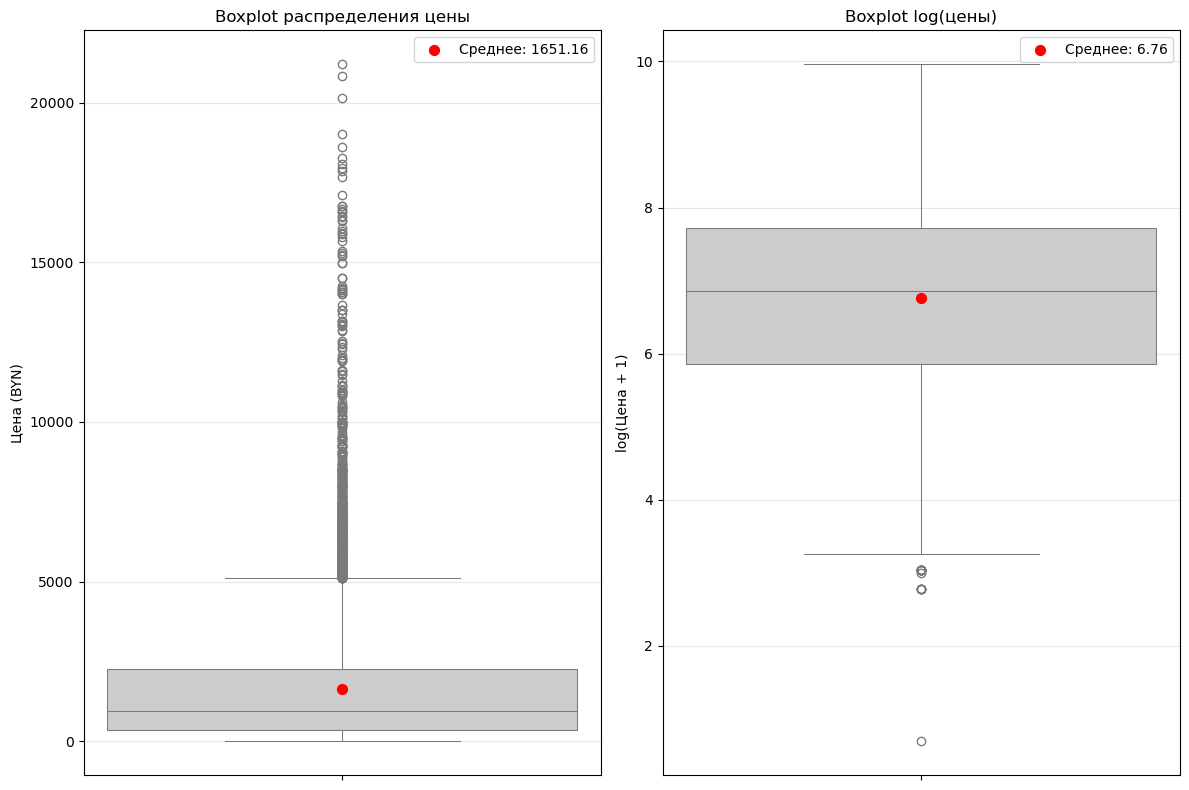

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# boxplot
sns.boxplot(data=df, y="price_byn", color='#CCCCCC', linewidth=0.75, ax=axes[0])
mean_price = df["price_byn"].mean()
axes[0].scatter(0, mean_price, color='red', s=50, zorder=3, label=f'Среднее: {mean_price:.2f}')
axes[0].set_ylabel("Цена (BYN)")
axes[0].set_title("Boxplot распределения цены")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# log boxplot
log_price = np.log1p(df["price_byn"])
sns.boxplot(y=log_price, color='#CCCCCC', linewidth=0.75, ax=axes[1])
mean_log_price = log_price.mean()
axes[1].scatter(0, mean_log_price, color='red', s=50, zorder=3, label=f'Среднее: {mean_log_price:.2f}')
axes[1].set_ylabel("log(Цена + 1)")
axes[1].set_title("Boxplot log(цены)")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

В нашем случае в непрологарифмированной версии графика наблюдается большое количество выбросов, что связано с особенностями логнормального распределения. Оставим эти объекты так как они важны для правильного предсказания цены на дорогих объектах.

### Зависимость цены от времени публикации

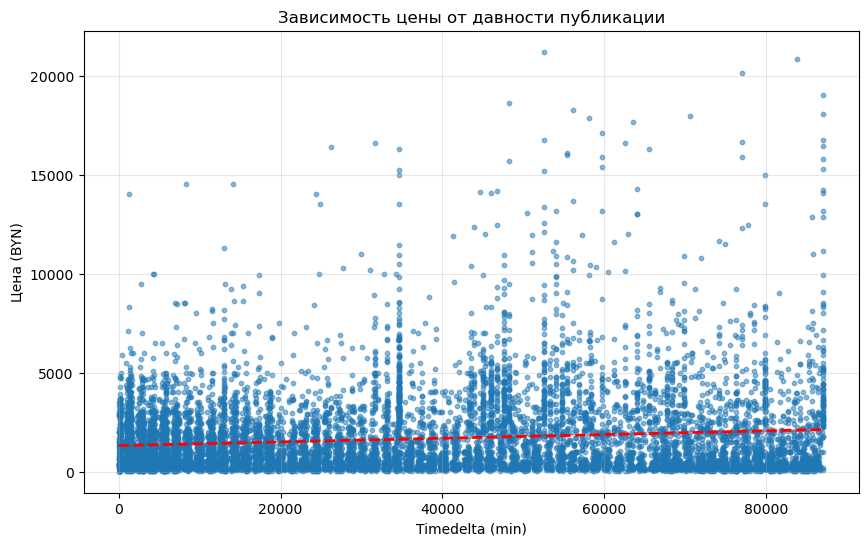

In [36]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="timedelta_minutes", y="price_byn",
            scatter_kws={'alpha':0.5, 's':10},
            line_kws={'color':'red', 'linewidth':2, 'linestyle':'--'})
plt.xlabel("Timedelta (min)")
plt.ylabel("Цена (BYN)")
plt.title("Зависимость цены от давности публикации")
plt.grid(True, alpha=0.3)
plt.show()

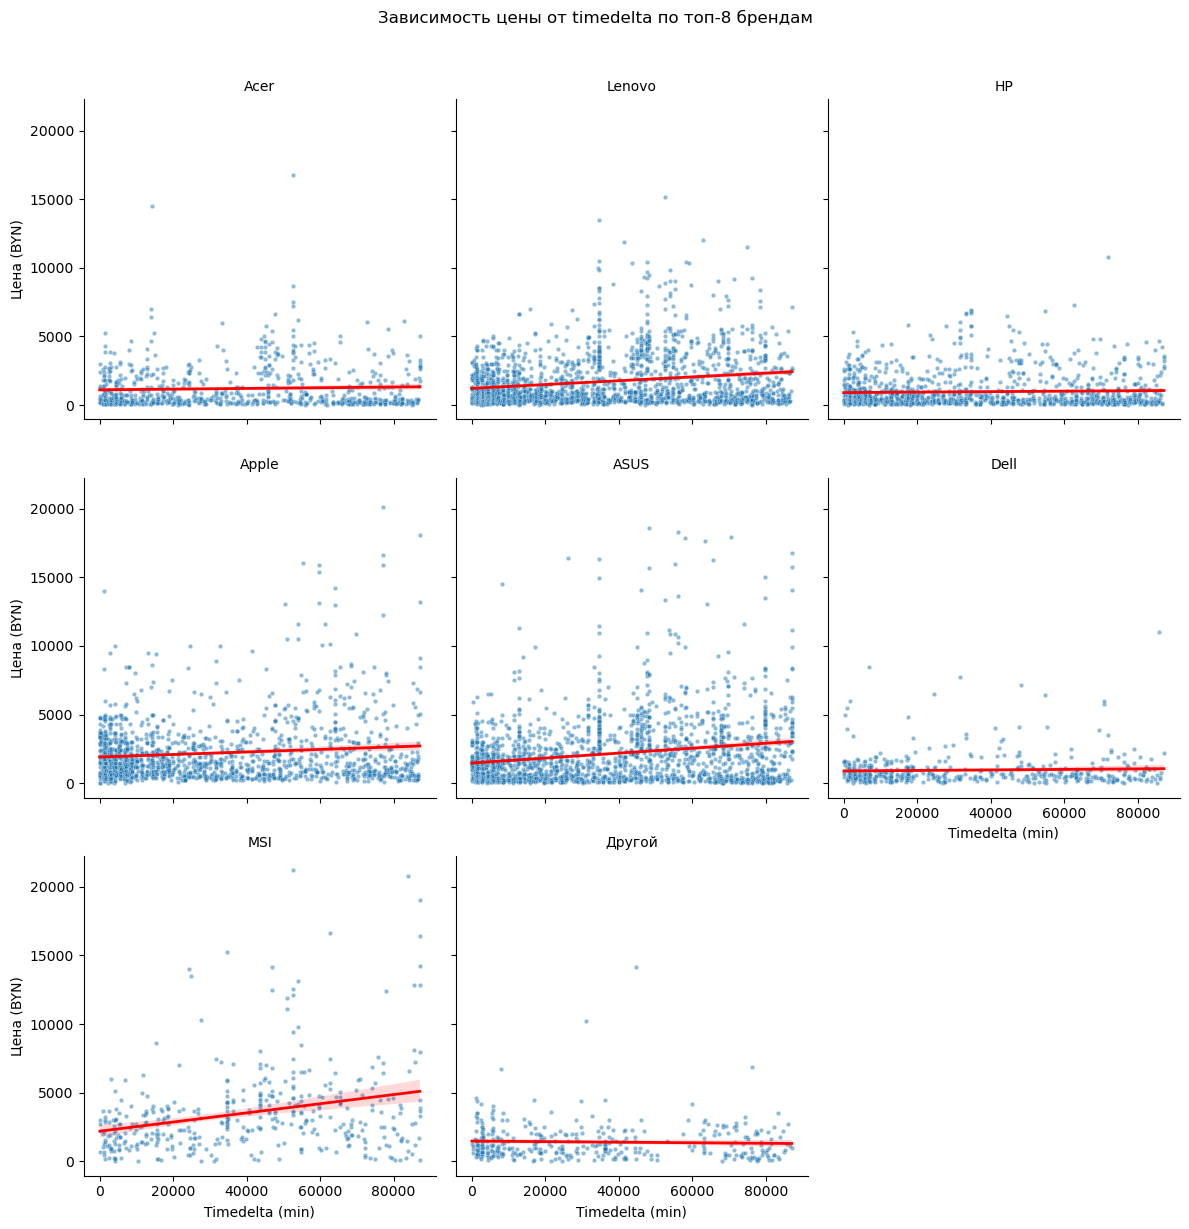

In [37]:
top_5_brands = df['brand'].value_counts().head(8).index.tolist()
df_top_5 = df[df['brand'].isin(top_5_brands)]

g = sns.FacetGrid(df_top_5, col="brand", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.scatterplot, "timedelta_minutes", "price_byn", alpha=0.5, s=10)
g.map(sns.regplot, "timedelta_minutes", "price_byn", 
      scatter=False, color='red', line_kws={'linewidth':2})
g.set_axis_labels("Timedelta (min)", "Цена (BYN)")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Зависимость цены от timedelta по топ-8 брендам", y=1.02)
plt.tight_layout()
plt.show()

Наблюдается очень слабая кореляция с давностью публикации, что связано с тем, что ноутбуки по завышенным ценам дольше продаются.

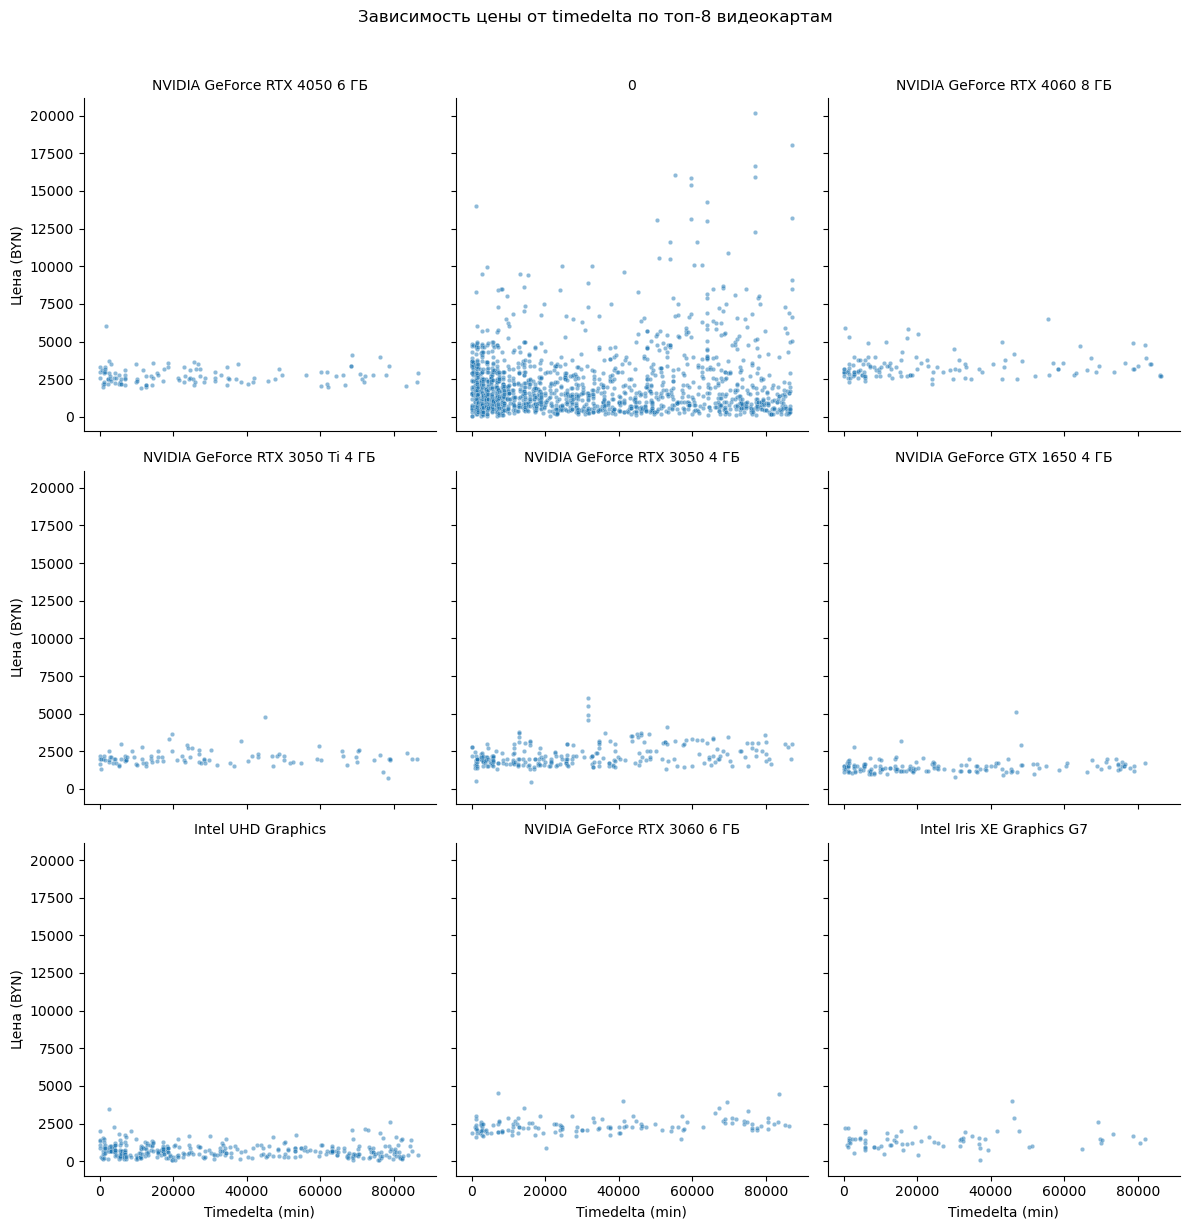

In [38]:
top_8_videocards = df['videocard_brand'].value_counts().head(9).index.tolist()
df_top_8_vc = df[df['videocard_brand'].isin(top_8_videocards)]

g = sns.FacetGrid(df_top_8_vc, col="videocard_brand", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.scatterplot, "timedelta_minutes", "price_byn", alpha=0.5, s=10)
g.set_axis_labels("Timedelta (min)", "Цена (BYN)")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Зависимость цены от timedelta по топ-8 видеокартам", y=1.02)
plt.tight_layout()
plt.show()

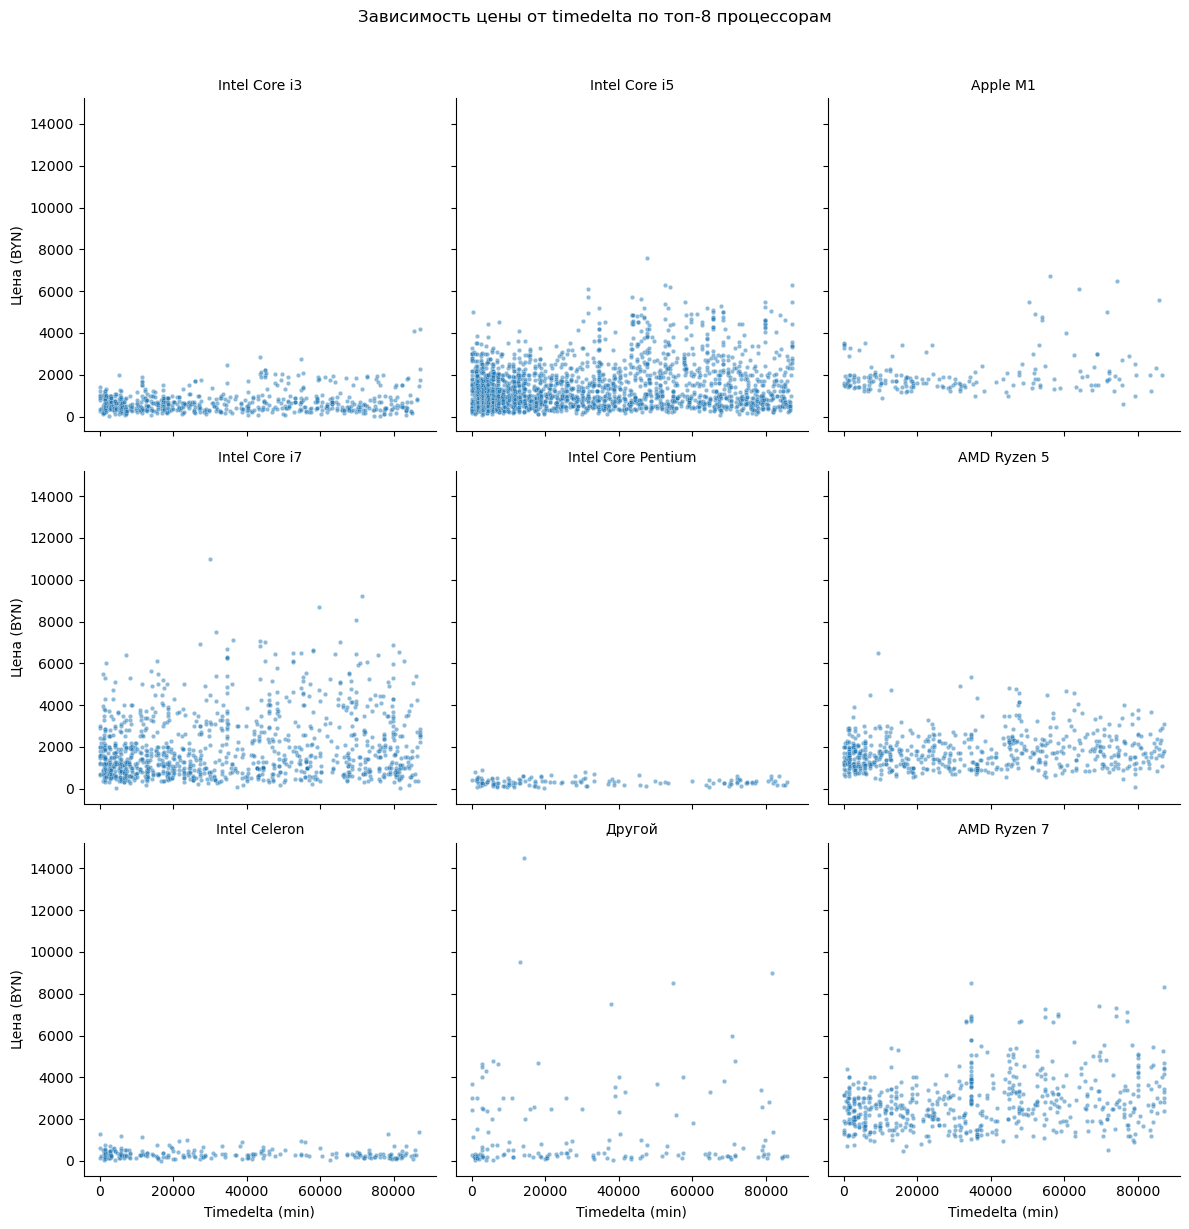

In [39]:
top_processors = df['processor'].value_counts().head(9).index.tolist()
df_top_proc = df[df['processor'].isin(top_processors)]

g = sns.FacetGrid(df_top_proc, col="processor", col_wrap=3, height=4, sharex=True, sharey=True)
g.map(sns.scatterplot, "timedelta_minutes", "price_byn", alpha=0.5, s=10)
g.set_axis_labels("Timedelta (min)", "Цена (BYN)")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Зависимость цены от timedelta по топ-8 процессорам", y=1.02)
plt.tight_layout()
plt.show()

Как и предполагалось. Видеокарта и процесссор определяют нижнюю планку цены ноутбка.

Text(0.5, 1.0, 'Распределение значений диагонали ноутбука')

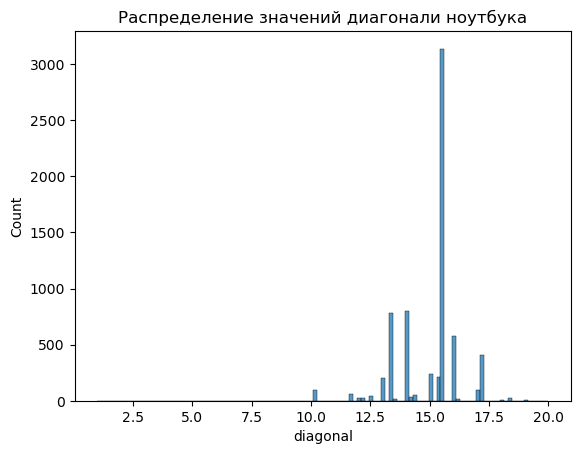

In [40]:
sns.histplot(data=df, x='diagonal')
plt.title('Распределение значений диагонали ноутбука')

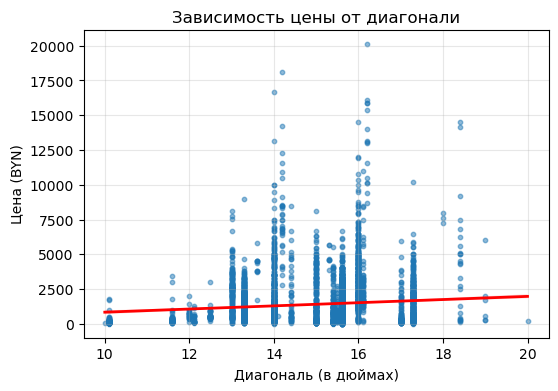

In [41]:
plt.figure(figsize=(6, 4))
sns.regplot(data=df[df['diagonal'] > 2.5], x="diagonal", y="price_byn",
            scatter_kws={'alpha':0.5, 's':10},
            line_kws={'color':'red', 'linewidth':2, 'linestyle':'-'})
plt.xlabel("Диагональ (в дюймах)")
plt.ylabel("Цена (BYN)")
plt.title("Зависимость цены от диагонали")
plt.grid(True, alpha=0.3)

In [42]:
df = df.drop(['ad_id'], axis=1)

### Матрица кореляций

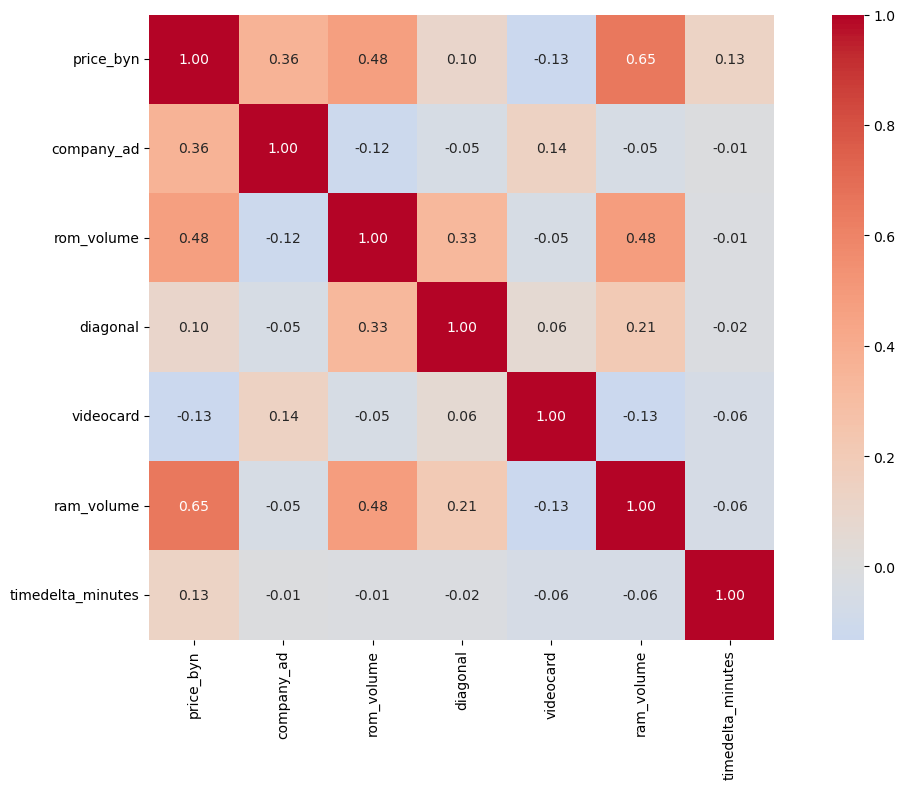

In [43]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.tight_layout()
plt.show()